<a href="https://www.kaggle.com/code/sonawanelalitsunil/student-study-habits-2025-ml-62-93?scriptVersionId=250203423" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/student-study-habits/student_study_habits.csv


## Title: Student Study Habits 2025

## Description:
This dataset captures various aspects of students' study habits, including their preferred study times, duration of daily study, use of digital tools, participation in group study, and methods of note-taking. It aims to identify patterns that contribute to academic performance and student satisfaction. The insights derived can help educators tailor learning strategies, improve academic outcomes, and support personalized learning experiences. Analysis of this dataset can also reveal trends in modern study behaviors, such as reliance on online resources versus traditional methods.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/student-study-habits/student_study_habits.csv')

In [3]:
df.head()

,study_hours_per_week,sleep_hours_per_day,attendance_percentage,assignments_completed,final_grade,participation_level_Low,participation_level_Medium,internet_access_Yes,parental_education_High School,parental_education_Master's,parental_education_PhD,extracurricular_Yes,part_time_job_Yes
0,0.527230,0.685236,0.993245,0.222222,71.104897,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.421400,0.881883,0.883478,0.555556,62.240021,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.552393,0.220286,0.683469,1.000000,65.268855,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.698283,0.612594,0.520094,0.222222,66.609921,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0.405419,0.369871,0.831127,0.333333,58.967484,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0


In [4]:
df.tail()

,study_hours_per_week,sleep_hours_per_day,attendance_percentage,assignments_completed,final_grade,participation_level_Low,participation_level_Medium,internet_access_Yes,parental_education_High School,parental_education_Master's,parental_education_PhD,extracurricular_Yes,part_time_job_Yes
495,0.534263,0.443780,1.000000,0.222222,67.032033,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0
496,0.271570,0.859537,1.000000,0.333333,57.419677,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
497,0.412721,0.628169,0.949083,0.555556,74.950594,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
498,0.298508,0.385764,0.906468,0.333333,55.271003,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
499,0.213978,0.614517,0.806687,0.777778,60.375414,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   study_hours_per_week            500 non-null    float64
 1   sleep_hours_per_day             500 non-null    float64
 2   attendance_percentage           500 non-null    float64
 3   assignments_completed           500 non-null    float64
 4   final_grade                     500 non-null    float64
 5   participation_level_Low         500 non-null    float64
 6   participation_level_Medium      500 non-null    float64
 7   internet_access_Yes             500 non-null    float64
 8   parental_education_High School  500 non-null    float64
 9   parental_education_Master's     500 non-null    float64
 10  parental_education_PhD          500 non-null    float64
 11  extracurricular_Yes             500 non-null    float64
 12  part_time_job_Yes               500 

In [6]:
df.describe()

,study_hours_per_week,sleep_hours_per_day,attendance_percentage,assignments_completed,final_grade,participation_level_Low,participation_level_Medium,internet_access_Yes,parental_education_High School,parental_education_Master's,parental_education_PhD,extracurricular_Yes,part_time_job_Yes
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000
mean,0.445603,0.506387,0.684110,0.533556,63.753071,0.202000,0.484000,0.890000,0.268000,0.228000,0.07800,0.618000,0.316000
std,0.162325,0.194923,0.214918,0.276109,7.114183,0.401894,0.500244,0.313203,0.443361,0.419963,0.26844,0.486363,0.465379
min,0.000000,0.000000,0.000000,0.000000,40.200403,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,0.327727,0.380942,0.530386,0.333333,58.813933,0.000000,0.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,0.446577,0.505706,0.697383,0.555556,63.822553,0.000000,0.000000,1.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,0.550575,0.630248,0.844194,0.777778,68.588277,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,92.007807,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [7]:
df.dtypes

study_hours_per_week              float64
sleep_hours_per_day               float64
attendance_percentage             float64
assignments_completed             float64
final_grade                       float64
participation_level_Low           float64
participation_level_Medium        float64
internet_access_Yes               float64
parental_education_High School    float64
parental_education_Master's       float64
parental_education_PhD            float64
extracurricular_Yes               float64
part_time_job_Yes                 float64
dtype: object

In [8]:
df.shape

(500, 13)

In [9]:
df.isnull().sum()

study_hours_per_week              0
sleep_hours_per_day               0
attendance_percentage             0
assignments_completed             0
final_grade                       0
participation_level_Low           0
participation_level_Medium        0
internet_access_Yes               0
parental_education_High School    0
parental_education_Master's       0
parental_education_PhD            0
extracurricular_Yes               0
part_time_job_Yes                 0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.columns

Index(['study_hours_per_week', 'sleep_hours_per_day', 'attendance_percentage',
       'assignments_completed', 'final_grade', 'participation_level_Low',
       'participation_level_Medium', 'internet_access_Yes',
       'parental_education_High School', 'parental_education_Master's',
       'parental_education_PhD', 'extracurricular_Yes', 'part_time_job_Yes'],
      dtype='object')

## Data visualizations

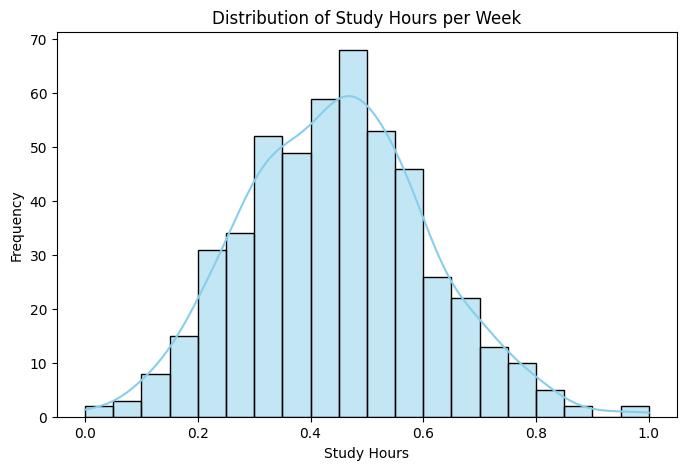

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(df['study_hours_per_week'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Study Hours per Week')
plt.xlabel('Study Hours')
plt.ylabel('Frequency')
plt.show()


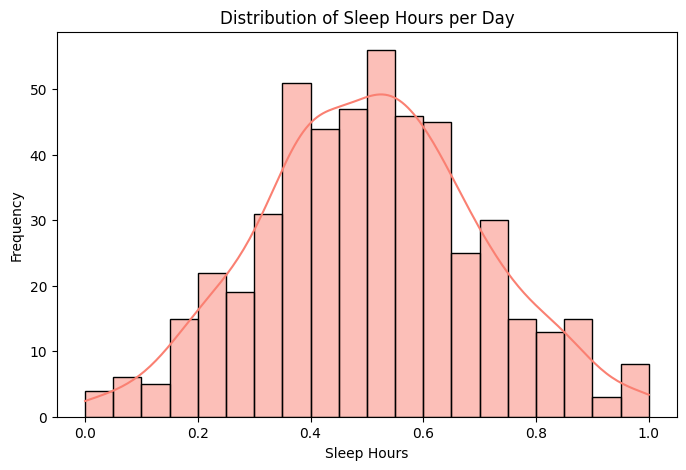

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(df['sleep_hours_per_day'], bins=20, kde=True, color='salmon')
plt.title('Distribution of Sleep Hours per Day')
plt.xlabel('Sleep Hours')
plt.ylabel('Frequency')
plt.show()


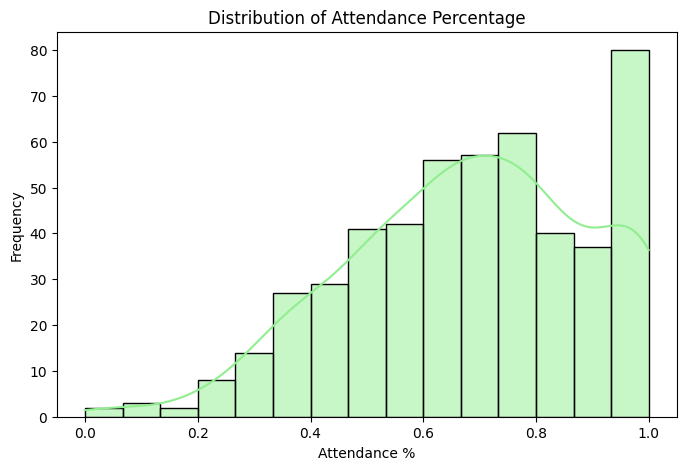

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(df['attendance_percentage'], bins=15, kde=True, color='lightgreen')
plt.title('Distribution of Attendance Percentage')
plt.xlabel('Attendance %')
plt.ylabel('Frequency')
plt.show()


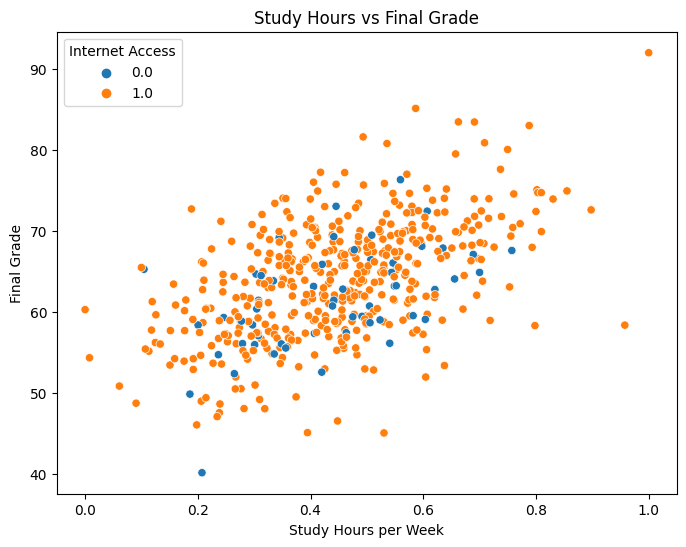

In [15]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='study_hours_per_week', y='final_grade', data=df, hue='internet_access_Yes')
plt.title('Study Hours vs Final Grade')
plt.xlabel('Study Hours per Week')
plt.ylabel('Final Grade')
plt.legend(title='Internet Access')
plt.show()


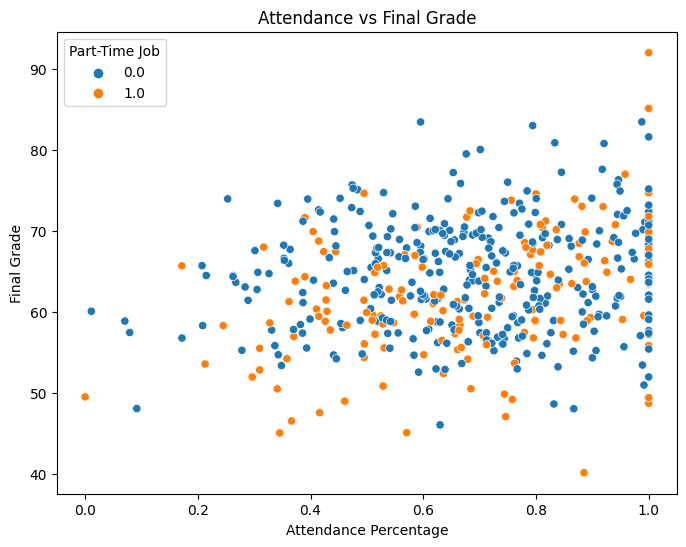

In [16]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='attendance_percentage', y='final_grade', data=df, hue='part_time_job_Yes')
plt.title('Attendance vs Final Grade')
plt.xlabel('Attendance Percentage')
plt.ylabel('Final Grade')
plt.legend(title='Part-Time Job')
plt.show()


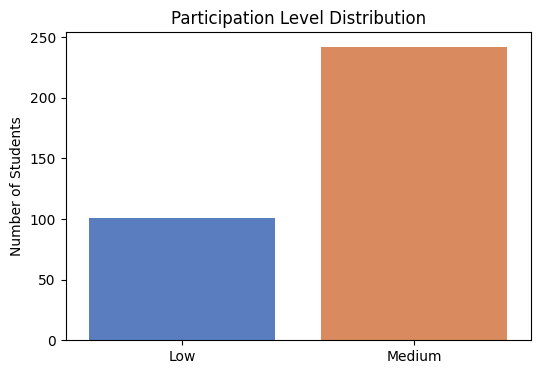

In [17]:
participation_levels = ['participation_level_Low', 'participation_level_Medium']
counts = df[participation_levels].sum()

plt.figure(figsize=(6, 4))
sns.barplot(x=counts.index.str.replace('participation_level_', ''), y=counts.values, palette='muted')
plt.title('Participation Level Distribution')
plt.ylabel('Number of Students')
plt.show()


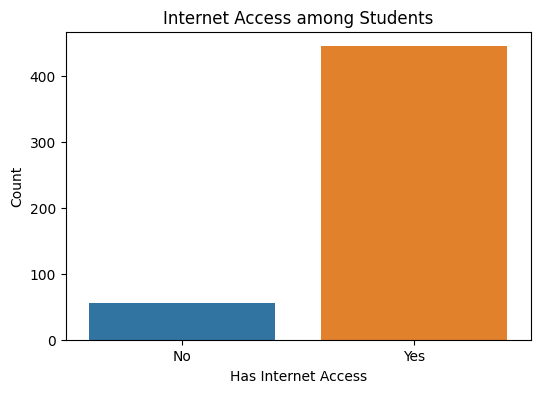

In [18]:
plt.figure(figsize=(6, 4))
sns.countplot(x='internet_access_Yes', data=df)
plt.title('Internet Access among Students')
plt.xlabel('Has Internet Access')
plt.ylabel('Count')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()


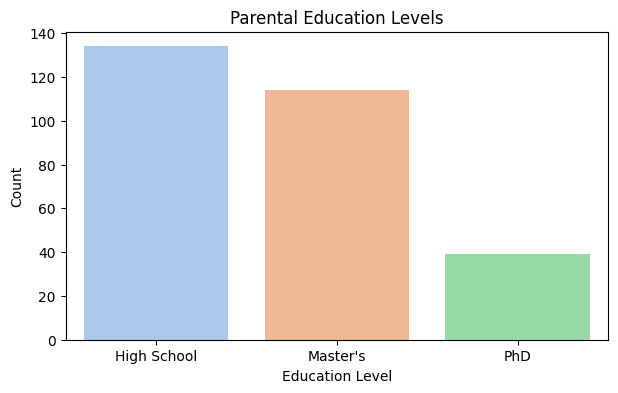

In [19]:
edu_cols = ['parental_education_High School', "parental_education_Master's", 'parental_education_PhD']
edu_counts = df[edu_cols].sum()

plt.figure(figsize=(7, 4))
sns.barplot(x=edu_counts.index.str.replace('parental_education_', ''), y=edu_counts.values, palette='pastel')
plt.title('Parental Education Levels')
plt.ylabel('Count')
plt.xlabel('Education Level')
plt.show()


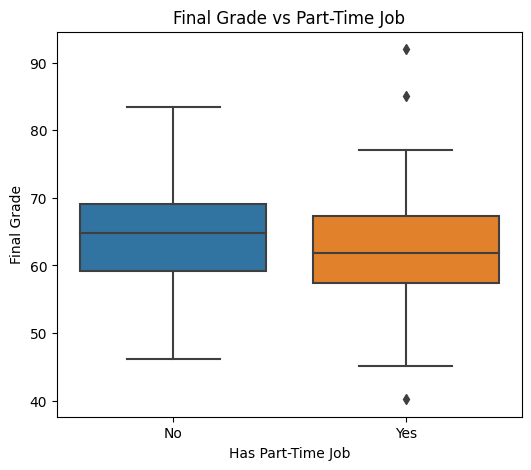

In [20]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='part_time_job_Yes', y='final_grade', data=df)
plt.title('Final Grade vs Part-Time Job')
plt.xlabel('Has Part-Time Job')
plt.ylabel('Final Grade')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()


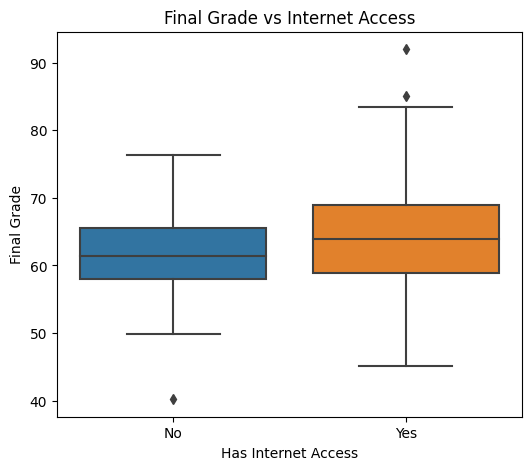

In [21]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='internet_access_Yes', y='final_grade', data=df)
plt.title('Final Grade vs Internet Access')
plt.xlabel('Has Internet Access')
plt.ylabel('Final Grade')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()


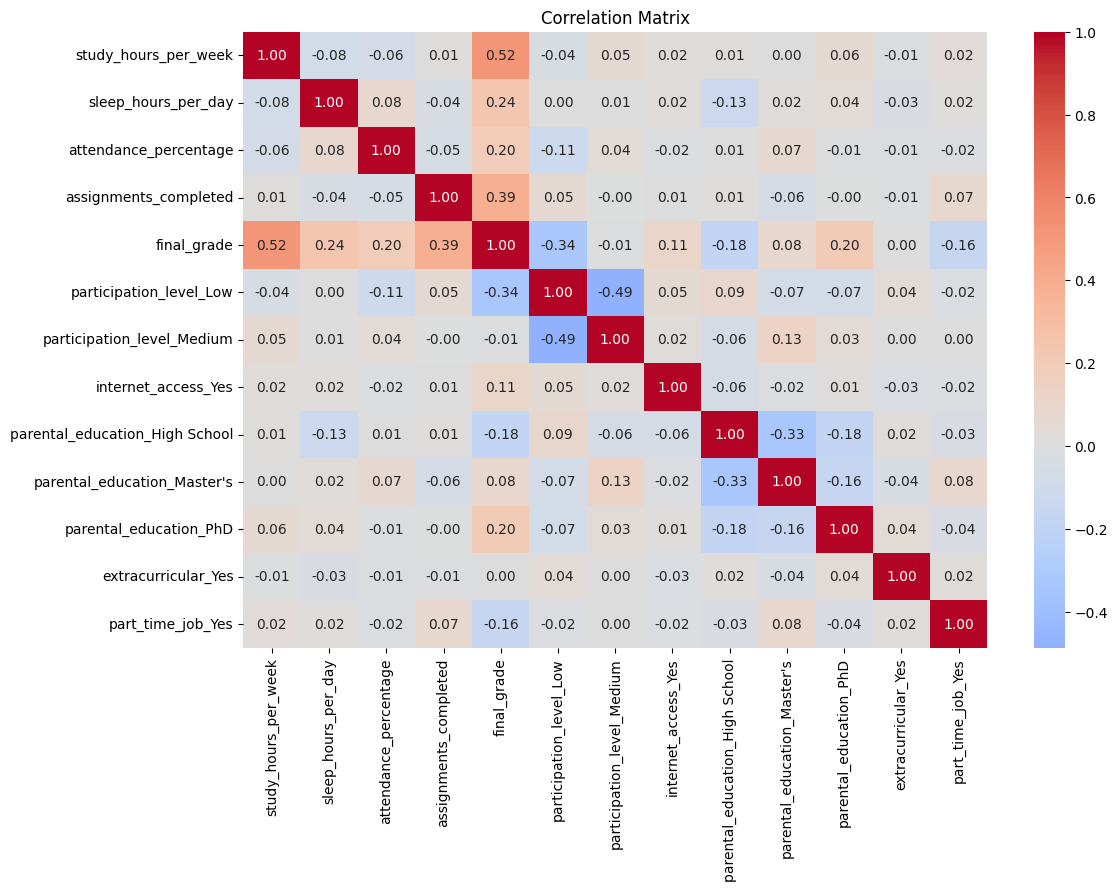

In [22]:
plt.figure(figsize=(12, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()


## Predictive modeling

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [24]:
# Boolean columns: convert from Yes/No to 1/0
binary_columns = ['internet_access_Yes', 'extracurricular_Yes', 'part_time_job_Yes']
df[binary_columns] = df[binary_columns].astype(int)

# Participation level: One-hot to single label (Low, Medium, High)
df['participation_level'] = df[['participation_level_Low', 'participation_level_Medium']].idxmax(axis=1)
df['participation_level'] = df['participation_level'].map({
    'participation_level_Low': 'Low',
    'participation_level_Medium': 'Medium'
}).fillna('High')  # If both are 0, assume High

# Encode participation level
df['participation_level'] = LabelEncoder().fit_transform(df['participation_level'])

# Parental education
df['parental_education'] = df[['parental_education_High School', "parental_education_Master's", 'parental_education_PhD']].idxmax(axis=1)
df['parental_education'] = df['parental_education'].str.replace("parental_education_", "")
df['parental_education'] = LabelEncoder().fit_transform(df['parental_education'])

# Drop one-hot columns
df = df.drop(columns=[
    'participation_level_Low', 'participation_level_Medium',
    'parental_education_High School', "parental_education_Master's", 'parental_education_PhD'
])

In [25]:
X = df.drop('final_grade', axis=1)
y = df['final_grade']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [26]:


models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'Gradient Boosting': GradientBoostingRegressor(),
    'Support Vector Regressor': SVR()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results[name] = {
        'MSE': round(mse, 2),
        'R2 Score': round(r2 * 100, 2)
    }

# Display results
results_df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})
print(results_df)


                      Model    MSE  R2 Score
0         Linear Regression  20.88     62.93
1             Decision Tree  52.84      6.19
2             Random Forest  30.05     46.65
3         Gradient Boosting  26.11     53.64
4  Support Vector Regressor  35.64     36.72


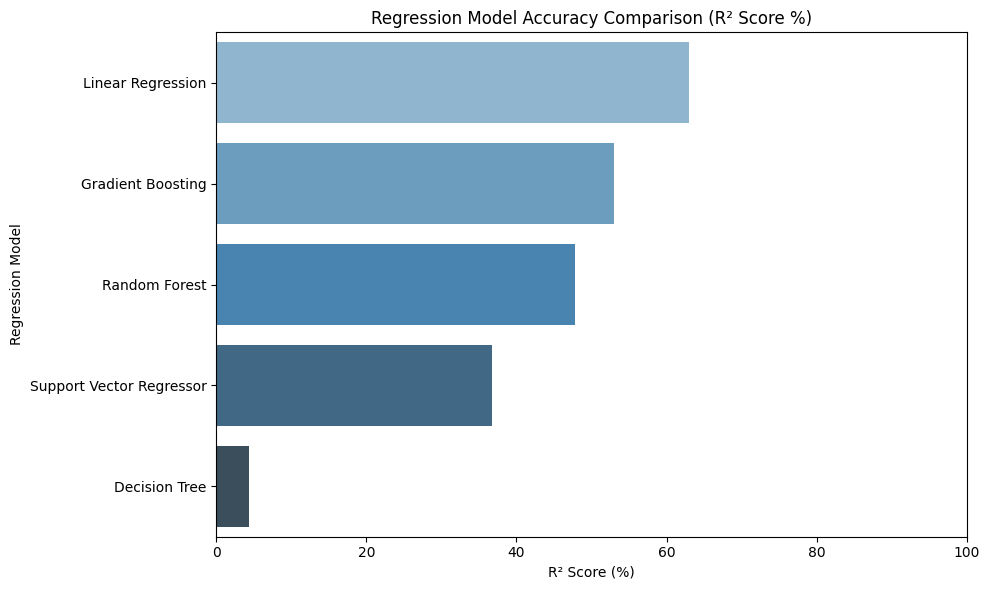

In [27]:
# Create the DataFrame from your results
results_df = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting',
        'Support Vector Regressor'
    ],
    'R2 Score (%)': [62.93, 4.39, 47.80, 52.99, 36.72]
})

# Sort by R2 Score
results_df = results_df.sort_values(by='R2 Score (%)', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='R2 Score (%)', y='Model', data=results_df, palette='Blues_d')
plt.title('Regression Model Accuracy Comparison (R² Score %)')
plt.xlabel('R² Score (%)')
plt.ylabel('Regression Model')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

## Thank you pls upvote!!!